In [1]:
import pyarrow as pa
import uproot
import awkward as ak
import numpy as np
from tensordict import TensorDict, MemoryMappedTensor 
from hepstats.modeling import bayesian_blocks
from scipy.stats import chisquare

import vector
vector.register_awkward()


import hist
import mplhep
from matplotlib import pyplot as plt

In [0]:
data_file_path = "/run/media/tanmaypani/Samsung-1tb/data/pp200_production_2012/2024-03-12/Events/13040037_0.tree.root"
events = uproot.concatenate([f"{data_file_path}:Events"])

coordinates = ["pt", "eta", "phi", "e", "charge"]
branchNames = ["Pt", "Eta", "Phi", "E", "Charge"]

tracks = ak.zip(dict(zip(coordinates, [events[f"tracks._{branch}"] for branch in branchNames])), with_name="Momentum4D")
towers = ak.zip(dict(zip(coordinates, [events[f"towers._{branch}"] for branch in branchNames])), with_name="Momentum4D")

towers = ak.drop_none(ak.mask(towers, towers.et > 2.0), axis=-1)
  
tracks[0:10].pt.show()    
print(ak.fill_none(ak.max(tracks[0:10].pt, axis=-1), value=0) < 30.0)    
towers[0:10].pt.show()   
ak.concatenate([tracks, towers], axis=-1)[0:10].pt.show()

 

[[],
 [],
 [6.05],
 [2.52],
 [],
 [4.14],
 [2.25, 5.29],
 [3.64],
 [10.1, 2.12, 2.19],
 []]
[True, True, True, True, True, True, True, True, True, True]
[[],
 [5.99],
 [4.36],
 [4.51],
 [4.53],
 [6.02],
 [2.32, 10.4],
 [],
 [4.14],
 [5.33]]
[[],
 [5.99],
 [6.05, 4.36],
 [2.52, 4.51],
 [4.53],
 [4.14, 6.02],
 [2.25, 5.29, 2.32, 10.4],
 [3.64],
 [10.1, 2.12, 2.19, 4.14],
 [5.33]]


In [4]:
pt_hat_bin_edges = ["11", "15", "20", "25", "35", "45", "55", "infty"]
#pt_hat_bin_edges = ["11", "15", "20", "25", "35", "45", "55"]
pt_hat_bins = [f"ptHat{low}to{high}" for low, high in zip(pt_hat_bin_edges[:-1], pt_hat_bin_edges[1:])]

data_folder = "outputs/30May25-1147"
unfolded_folded = f"{data_folder}/multifolding_1"
n_iter = 5
unfolded_wts = np.load(f"{unfolded_folded}/multifolded-wts-iter{n_iter}.npz")

data_buffer = pa.memory_map("outputs/jets-conPtMin0.2.arrow")
data_table = pa.ipc.open_file(data_buffer).read_all()

gen_match_buffers = [pa.memory_map(f"{data_folder}/{pth_bin}/gen-matches.arrow", "rb") for pth_bin in pt_hat_bins] 
reco_match_buffers = [pa.memory_map(f"{data_folder}/{pth_bin}/reco-matches.arrow", "rb") for pth_bin in pt_hat_bins] 
gen_miss_buffers = [pa.memory_map(f"{data_folder}/{pth_bin}/misses.arrow", "rb") for pth_bin in pt_hat_bins] 
reco_fake_buffers = [pa.memory_map(f"{data_folder}/{pth_bin}/fakes.arrow", "rb") for pth_bin in pt_hat_bins] 

gen_match_table = pa.concat_tables([pa.ipc.open_file(buff).read_all() for buff in gen_match_buffers])
reco_match_table = pa.concat_tables([pa.ipc.open_file(buff).read_all() for buff in reco_match_buffers])
gen_miss_table = pa.concat_tables([pa.ipc.open_file(buff).read_all() for buff in gen_miss_buffers])
reco_fake_table = pa.concat_tables([pa.ipc.open_file(buff).read_all() for buff in reco_fake_buffers])

#gen_table = pa.concat_tables([gen_match_table, gen_miss_table])
gen_table = gen_match_table
reco_table = pa.concat_tables([reco_match_table, reco_fake_table])

In [14]:
print(len(gen_match_table))

2276498


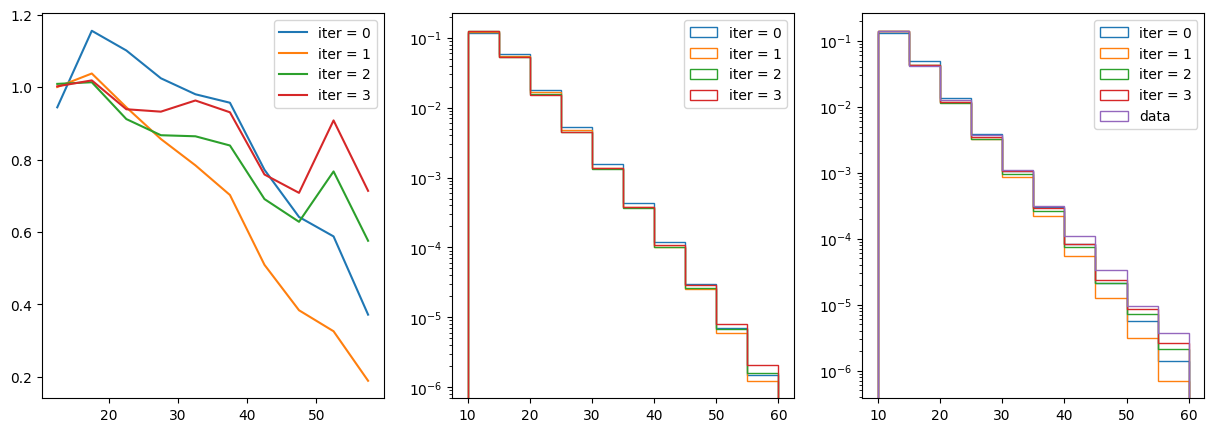

In [8]:
var = "pt"
data_hist, bins = np.histogram(data_table[var].to_numpy(), density=True, bins=10, range=[10, 60])
x = (bins[1:] + bins[:-1])/2.0
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i in range(n_iter-1):
    #print(f"arr_{2*i+1}", len(reco_table), len(unfolded_wts[f"arr_{2*i+1}"]), len(unfolded_wts[f"arr_{2*i}"]))
    #continue
    reco_hist, _ = np.histogram(reco_table[var].to_numpy(), weights=unfolded_wts[f"arr_{2*i+1}"], density=True, bins=bins)
    reco_data_ratio = reco_hist / data_hist
    ax[0].plot(x, reco_data_ratio, label=f"iter = {i}")
    ax[1].hist(gen_table[var].to_numpy(), weights=unfolded_wts[f"arr_{2*i}"], density=True, bins=bins, label=f"iter = {i}", histtype="step")
    ax[2].hist(reco_table[var].to_numpy(), weights=unfolded_wts[f"arr_{2*i+1}"], density=True, bins=bins, label=f"iter = {i}", histtype="step")
    
ax[2].hist(data_table[var].to_numpy(), density=True, bins=bins, histtype="step", label="data")
ax[1].set_yscale("log")
ax[2].set_yscale("log")
ax[0].legend()
ax[1].legend()
ax[2].legend()

In [2]:
#data_buffer_incl = pa.memory_map("outputs/jets-conPtMin0.2.arrow")
data_buffer_incl = pa.memory_map("outputs/30May25-1147/ptHat35to45/gen-matches.arrow")
data_buffer_hc = pa.memory_map("outputs/jets-conPtMin2.0.arrow")
data_table_incl = pa.ipc.open_file(data_buffer_incl).read_all()
data_table_hc = pa.ipc.open_file(data_buffer_hc).read_all()

weights = data_table_incl["weight"].to_numpy()
weights = weights/np.mean(weights)

weights_hc = data_table_hc["weight"].to_numpy()
weights_hc = weights_hc/np.mean(weights_hc)

In [11]:
#print(data_table_incl["eta"].take([0]))
#print(data_table_incl["phi"].take([0]))
#print(data_table_incl["constit_pt"].take([0]))
#print(data_table_incl["constit_phi"].take([0]))
#print(data_table_incl["constit_eta"].take([0]))
print(pa.compute.list_slice(data_table_incl["constit_pt"], 0, 1).combine_chunks().flatten().take([0, 2, 5]))

[
  10.680026,
  11.041359,
  15.768019
]


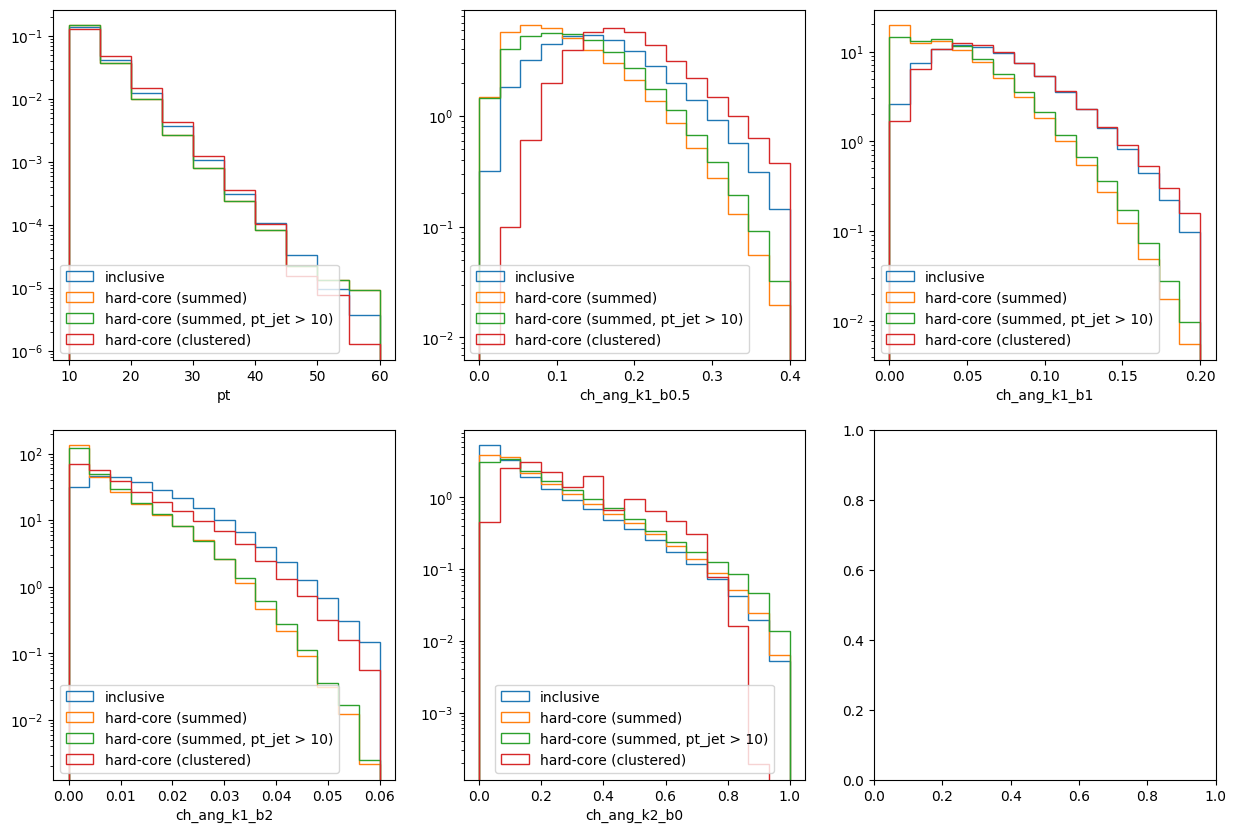

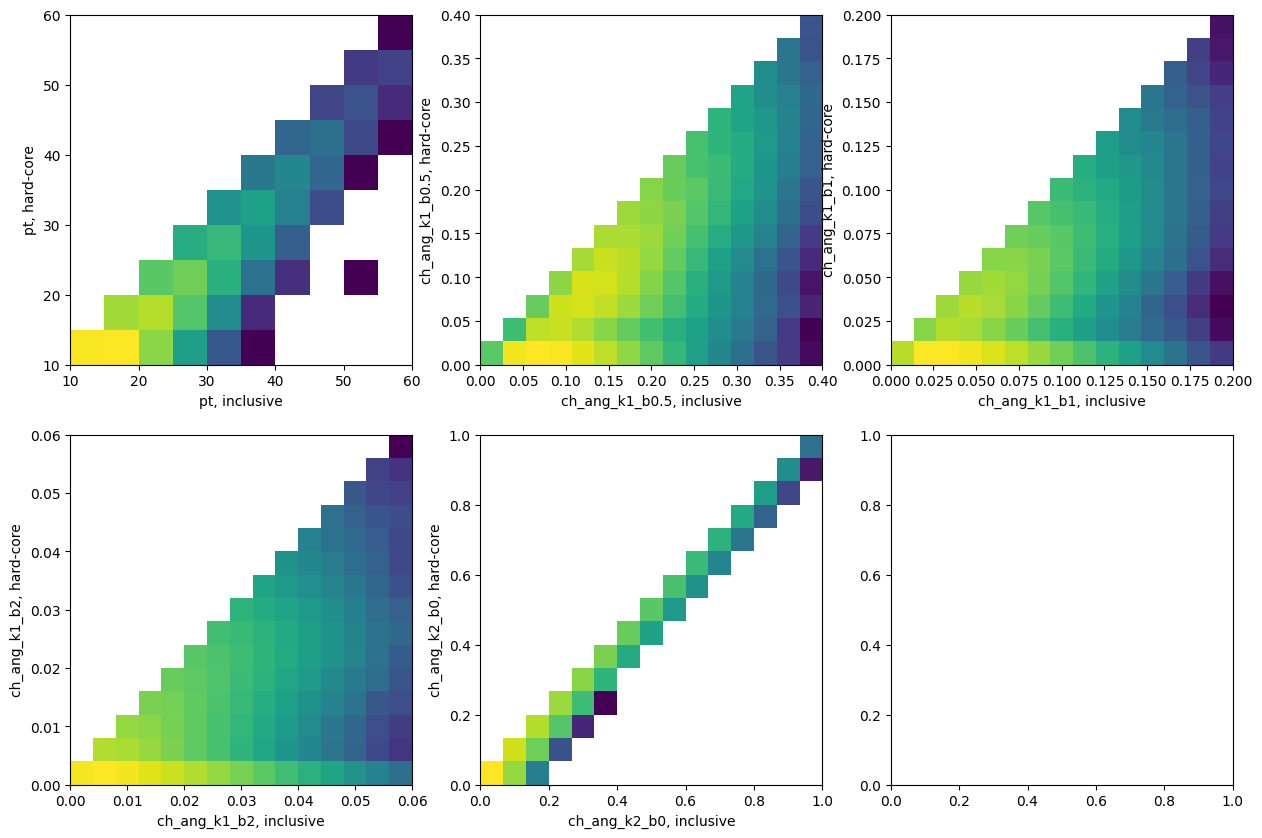

In [14]:
jet_columns = [
        "pt",
        "ch_ang_k1_b0.5",
        "ch_ang_k1_b1",
        "ch_ang_k1_b2",
        "ch_ang_k2_b0"]

ranges = [[10, 60], [0, 0.4], [0, 0.2], [0, 0.06], [0, 1.0]]
nbins = [10, 15, 15, 15, 15]        

nrows = 2
ncols = 3

hc_pt_sel = data_table_incl["hc_pt"].to_numpy() > 10

fig1, ax1 = plt.subplots(2, 3, figsize=(15, 10))
fig2, ax2 = plt.subplots(2, 3, figsize=(15, 10))
for icol, col in enumerate(jet_columns):
    row = icol // ncols
    colm = icol % ncols 
    incl_arr = data_table_incl[col].to_numpy()
    hc_arr = data_table_incl[f"hc_{col}"].to_numpy()
    
    hc_ncon_sel = hc_arr > 0
    hc_arr_sel = hc_ncon_sel & hc_pt_sel
    
    hc_arr_1 = data_table_hc[col].to_numpy()
    
    ax1[row, colm].hist(incl_arr, weights=weights, bins=nbins[icol], range=ranges[icol], density=True, label="inclusive", histtype="step")
    ax1[row, colm].hist(hc_arr[hc_ncon_sel], weights=weights[hc_ncon_sel], bins=nbins[icol], range=ranges[icol], density=True, label="hard-core (summed)", histtype="step")
    ax1[row, colm].hist(hc_arr[hc_arr_sel], weights=weights[hc_arr_sel], bins=nbins[icol], range=ranges[icol], density=True, label="hard-core (summed, pt_jet > 10)", histtype="step")
    ax1[row, colm].hist(hc_arr_1, weights=weights_hc, bins=nbins[icol], range=ranges[icol], density=True, label="hard-core (clustered)", histtype="step")
    ax1[row, colm].set_yscale("log")
    ax1[row, colm].set_xlabel(col)
    ax1[row, colm].legend()
    
    ax2[row, colm].hist2d(incl_arr, hc_arr, weights=weights, bins=[nbins[icol],nbins[icol]], range=[ranges[icol],ranges[icol]], density=True, norm="log")
    ax2[row, colm].set_xlabel(f"{col}, inclusive")
    ax2[row, colm].set_ylabel(f"{col}, hard-core")

In [3]:
import torch
from torchmodel.datasets import JetDataset, Batch, batch_collate
from torch.utils.data.dataset import ConcatDataset, Subset
from sklearn.model_selection import train_test_split

gen_match_ds = JetDataset(gen_match_table.select(["pt", "hc_pt"]), np.ones(len(gen_match_table)), sample_weights=np.ones(len(gen_match_table)))
gen_miss_ds = JetDataset(gen_miss_table.select(["pt", "hc_pt"]), np.ones(len(gen_miss_table)), sample_weights=np.ones(len(gen_miss_table)))

gen_ds = ConcatDataset([gen_match_ds, gen_miss_ds])

all_indices = np.arange(len(gen_ds))
train_indices, test_indices = train_test_split(all_indices, test_size=0.2)

gen_ds_subset = Subset(gen_ds, train_indices)

print(batch_collate(gen_ds_subset.__getitems__([1,2,3])).data["sample_weights"])

tensor([[1.],
        [1.],
        [1.]])


In [4]:
gen_match_ds.set_sample_weights(2.0*np.ones(len(gen_match_table)))
gen_miss_ds.set_sample_weights(2.0*np.ones(len(gen_miss_table)))

print(batch_collate(gen_ds_subset.__getitems__([1,2,3])).data["sample_weights"])

tensor([[2.],
        [2.],
        [2.]])


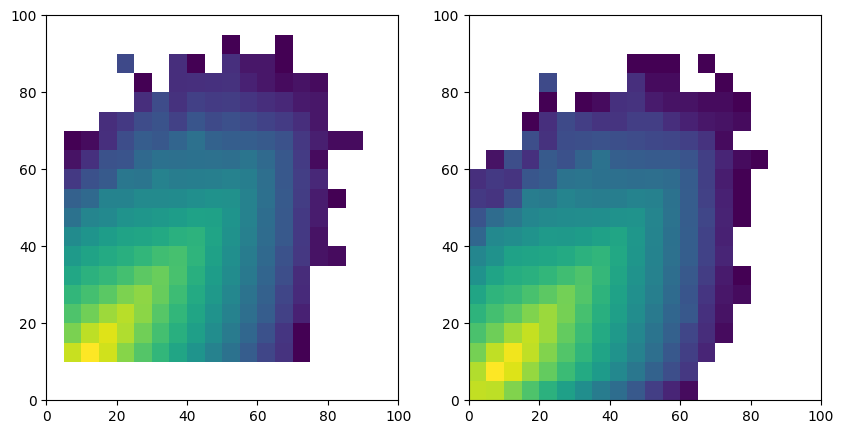

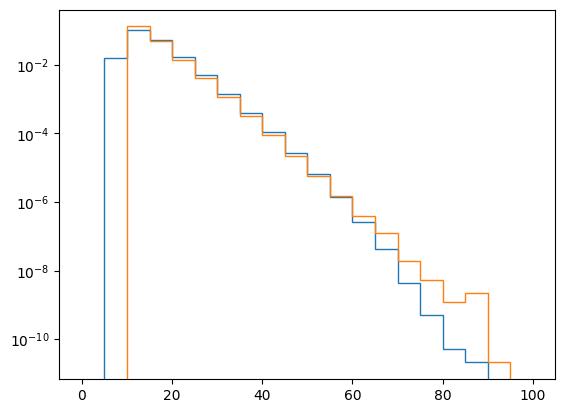

In [4]:
match_weights = gen_match_table["weight"].to_numpy()
match_weights = match_weights/np.mean(match_weights)
var_name = "pt"
bins = [20, 20]
ranges = [[0, 100],[0,100]]

gen_match_arr = gen_match_table[f"{var_name}"].to_numpy()
reco_match_arr = reco_match_table[f"{var_name}"].to_numpy()
gen_match_hc_arr = gen_match_table[f"hc_{var_name}"].to_numpy()
reco_match_hc_arr = reco_match_table[f"hc_{var_name}"].to_numpy()

fg, ax = plt.subplots(1,2, figsize=(10,5))
hists = ax[0].hist2d(gen_match_arr, reco_match_arr, weights=match_weights, bins=bins, range=ranges, density=True, norm="log")
hists = ax[1].hist2d(gen_match_hc_arr, reco_match_hc_arr, weights=match_weights, bins=bins, range=ranges, density=True, norm="log")

fg1 = plt.figure()
h = plt.hist(gen_match_arr, weights=match_weights, bins=bins[0], range=ranges[0], density=True, histtype="step")
h = plt.hist(reco_match_arr, weights=match_weights, bins=bins[1], range=ranges[1], density=True, histtype="step")
plt.yscale("log")

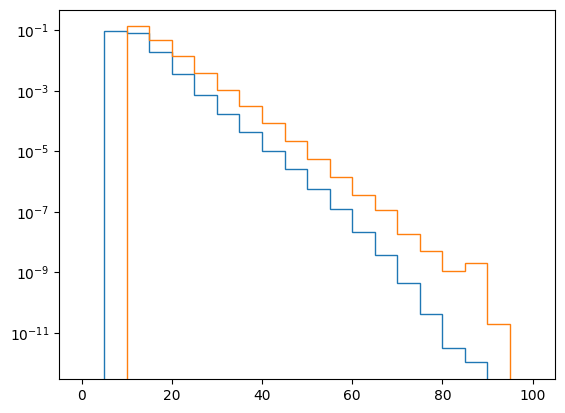

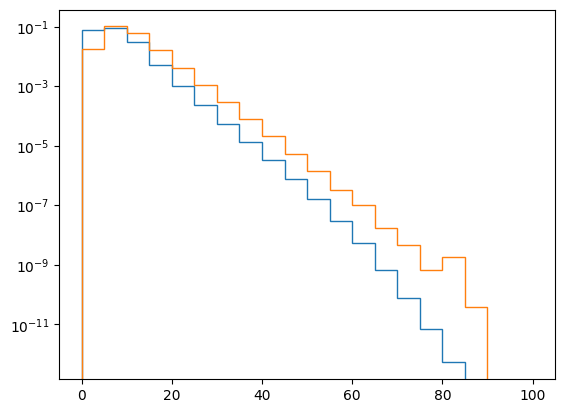

In [8]:
gen_weights = gen_table["weight"].to_numpy()
reco_weights = reco_table["weight"].to_numpy()
gen_weights = gen_weights/np.sum(gen_weights)
reco_weights = reco_weights/np.sum(reco_weights)

gen_arr = gen_table[f"{var_name}"].to_numpy()
gen_hc_arr = gen_table[f"hc_{var_name}"].to_numpy()
reco_arr = reco_table[f"{var_name}"].to_numpy()
reco_hc_arr = reco_table[f"hc_{var_name}"].to_numpy()

fig0 = plt.figure()
h = plt.hist(gen_arr, weights=gen_weights, bins=bins[0], range=ranges[0], density=True, histtype="step")
h = plt.hist(reco_arr, weights=reco_weights, bins=bins[1], range=ranges[1], density=True, histtype="step")
plt.yscale("log")

fig1 = plt.figure()
h = plt.hist(gen_hc_arr, weights=gen_weights, bins=bins[0], range=ranges[0], density=True, histtype="step")
h = plt.hist(reco_hc_arr, weights=reco_weights, bins=bins[1], range=ranges[1], density=True, histtype="step")
plt.yscale("log")

(array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 2.8847341e-07,
         0.0000000e+00, 0.0000000e+00]], shape=(50, 50)),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  

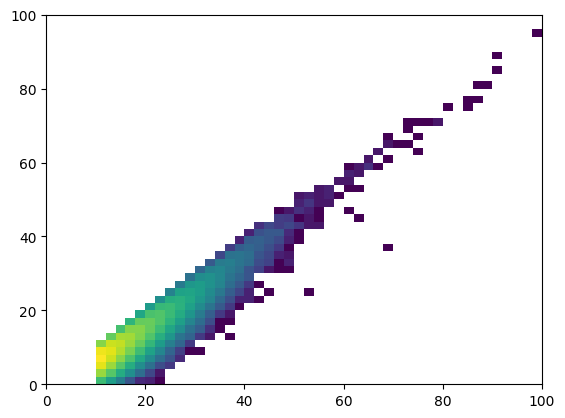